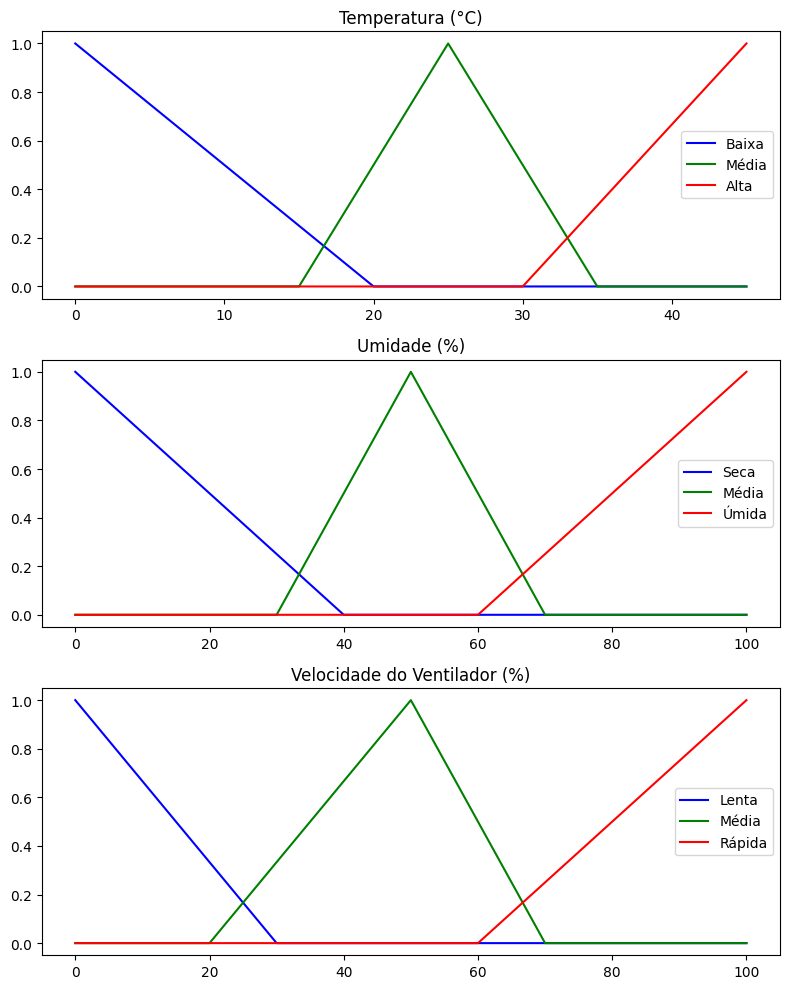

Temperatura = 28°C, Umidade = 65%
Velocidade calculada (fuzzy) = 45.60%


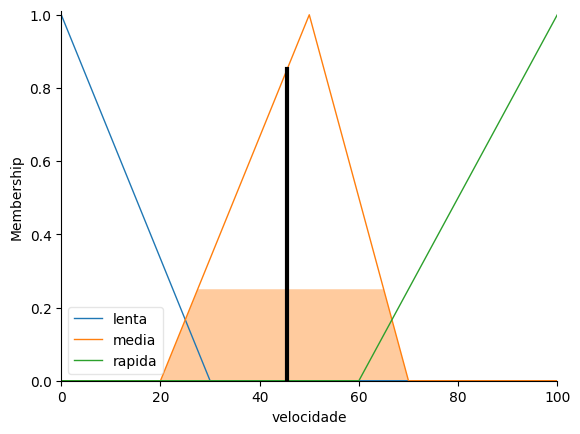

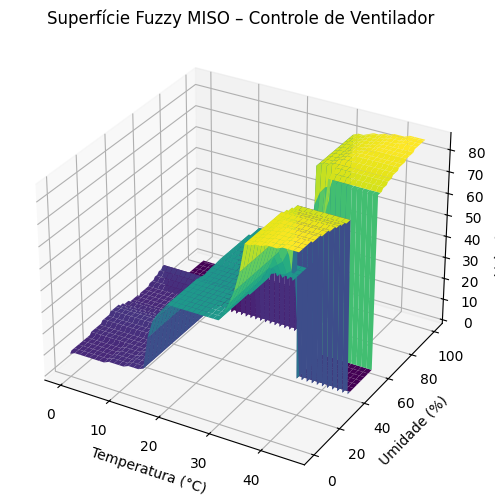

In [4]:
# ================================================================
# 🌡️ Exemplo Fuzzy MISO: Controle Automático de Ventilador
# Entradas: Temperatura (°C) e Umidade (%)
# Saída: Velocidade do Ventilador (%)
# ---------------------------------------------------------------
# Autor: Prof. Luis Ramirez (versão didática para Google Colab)
# Biblioteca: scikit-fuzzy
# ================================================================

!pip install scikit-fuzzy matplotlib numpy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Garantir renderização correta no Colab
%matplotlib inline

# ---------------------------------------------------------------
# 1️⃣ Definição das variáveis fuzzy
# ---------------------------------------------------------------
temperatura = ctrl.Antecedent(np.arange(0, 46, 1), 'temperatura')  # 0–45 °C
umidade = ctrl.Antecedent(np.arange(0, 101, 1), 'umidade')         # 0–100 %
velocidade = ctrl.Consequent(np.arange(0, 101, 1), 'velocidade')   # 0–100 %

# ---------------------------------------------------------------
# 2️⃣ Definição das funções de pertinência
# ---------------------------------------------------------------
temperatura['baixa'] = fuzz.trimf(temperatura.universe, [0, 0, 20])
temperatura['media'] = fuzz.trimf(temperatura.universe, [15, 25, 35])
temperatura['alta']  = fuzz.trimf(temperatura.universe, [30, 45, 45])

umidade['seca']  = fuzz.trimf(umidade.universe, [0, 0, 40])
umidade['media'] = fuzz.trimf(umidade.universe, [30, 50, 70])
umidade['umida'] = fuzz.trimf(umidade.universe, [60, 100, 100])

velocidade['lenta']  = fuzz.trimf(velocidade.universe, [0, 0, 30])
velocidade['media']  = fuzz.trimf(velocidade.universe, [20, 50, 70])
velocidade['rapida'] = fuzz.trimf(velocidade.universe, [60, 100, 100])

# ---------------------------------------------------------------
# 3️⃣ Visualização das funções de pertinência
# ---------------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

axs[0].plot(temperatura.universe, temperatura['baixa'].mf, 'b', label='Baixa')
axs[0].plot(temperatura.universe, temperatura['media'].mf, 'g', label='Média')
axs[0].plot(temperatura.universe, temperatura['alta'].mf, 'r', label='Alta')
axs[0].set_title('Temperatura (°C)')
axs[0].legend()

axs[1].plot(umidade.universe, umidade['seca'].mf, 'b', label='Seca')
axs[1].plot(umidade.universe, umidade['media'].mf, 'g', label='Média')
axs[1].plot(umidade.universe, umidade['umida'].mf, 'r', label='Úmida')
axs[1].set_title('Umidade (%)')
axs[1].legend()

axs[2].plot(velocidade.universe, velocidade['lenta'].mf, 'b', label='Lenta')
axs[2].plot(velocidade.universe, velocidade['media'].mf, 'g', label='Média')
axs[2].plot(velocidade.universe, velocidade['rapida'].mf, 'r', label='Rápida')
axs[2].set_title('Velocidade do Ventilador (%)')
axs[2].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 4️⃣ Definição das regras fuzzy (base de conhecimento)
# ---------------------------------------------------------------
rule1 = ctrl.Rule(temperatura['baixa'] & umidade['seca'],  velocidade['lenta'])
rule2 = ctrl.Rule(temperatura['baixa'] & umidade['media'], velocidade['lenta'])
rule3 = ctrl.Rule(temperatura['media'] & umidade['seca'],  velocidade['media'])
rule4 = ctrl.Rule(temperatura['media'] & umidade['media'], velocidade['media'])
rule5 = ctrl.Rule(temperatura['alta']  & umidade['seca'],  velocidade['rapida'])
rule6 = ctrl.Rule(temperatura['alta']  & umidade['umida'], velocidade['rapida'])

# ---------------------------------------------------------------
# 5️⃣ Criação do sistema de controle e simulação
# ---------------------------------------------------------------
sistema_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])
simulador = ctrl.ControlSystemSimulation(sistema_ctrl)

# Exemplo prático
simulador.input['temperatura'] = 28   # °C
simulador.input['umidade'] = 65       # %
simulador.compute()

print(f"Temperatura = 28°C, Umidade = 65%")
print(f"Velocidade calculada (fuzzy) = {simulador.output['velocidade']:.2f}%")

# Visualiza o resultado fuzzy na saída
velocidade.view(sim=simulador)
plt.show()

# ---------------------------------------------------------------
# 6️⃣ Geração da superfície 3D do sistema Fuzzy MISO
# ---------------------------------------------------------------
temp_range = np.arange(0, 46, 1)
umid_range = np.arange(0, 101, 1)
x, y = np.meshgrid(temp_range, umid_range)
z = np.zeros_like(x)

for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        simulador.input['temperatura'] = x[i, j]
        simulador.input['umidade'] = y[i, j]
        simulador.compute()
        if 'velocidade' in simulador.output:
          z[i, j] = simulador.output['velocidade']
        else:
          z[i, j] = 0 # Assign a default value if no output is produced


# ---------------------------------------------------------------
# 7️⃣ Visualização 3D da superfície fuzzy
# ---------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Umidade (%)')
ax.set_zlabel('Velocidade (%)')
ax.set_title('Superfície Fuzzy MISO – Controle de Ventilador')
plt.show()

In [10]:
!pip install scikit-fuzzy numpy matplotlib

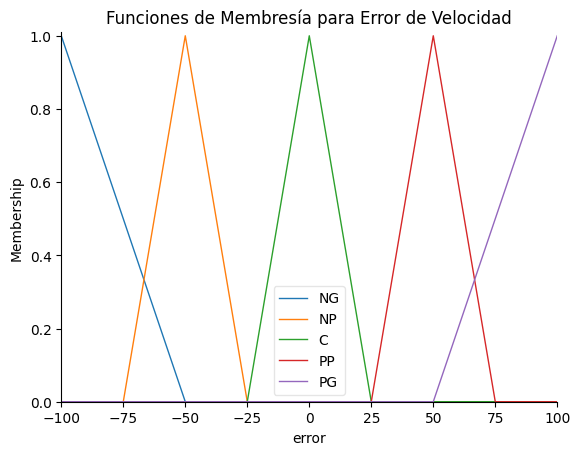

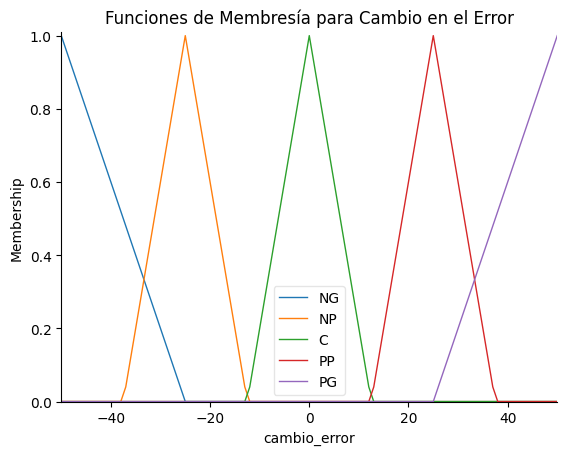

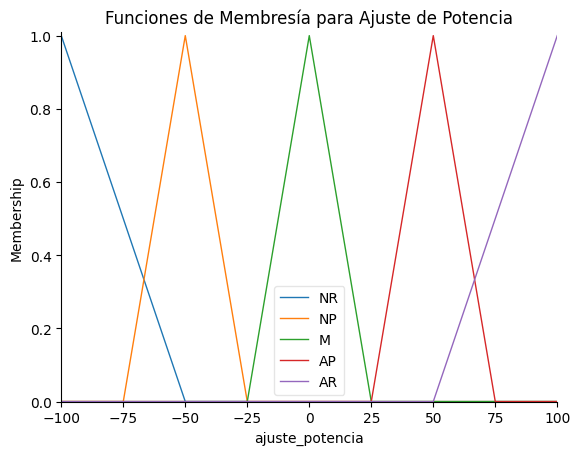

Ajuste de potencia recomendado: 50.00%


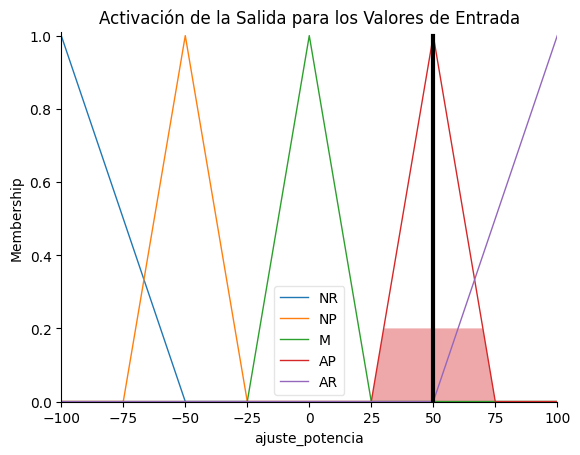

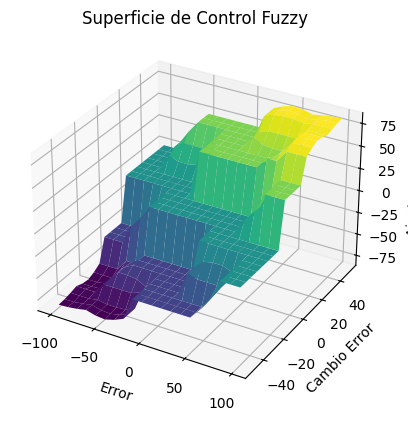

In [11]:
# Primero, instalamos la biblioteca necesaria para lógica fuzzy en Google Colab.
# scikit-fuzzy es una librería de Python para implementar sistemas fuzzy.
# Ejecútalo solo una vez en tu sesión de Colab.
!pip install -U scikit-fuzzy

# Importamos las bibliotecas necesarias.
import numpy as np  # Para manejar arrays y cálculos numéricos.
import skfuzzy as fuzz  # La librería principal para lógica fuzzy.
from skfuzzy import control as ctrl  # Módulo específico para sistemas de control fuzzy.
import matplotlib.pyplot as plt  # Para generar gráficas y visualizar resultados.

# --- Explicación general del ejemplo ---
# Ejemplo: Control de velocidad de un motor DC (como en robótica o automatización).
#
# Entradas (Inputs):
# 1. Error de velocidad: Diferencia entre la velocidad deseada y la actual (ej: si deseamos 100 rpm y actual es 80, error = 20).
#    - Universo: De -100 a 100 rpm (puede ser negativo si el motor va más rápido de lo deseado).
# 2. Cambio en el error: Cómo está cambiando el error con el tiempo (derivada del error, para anticipar cambios).
#    - Universo: De -50 a 50 rpm/s (cambio por segundo).
#
# Salida (Output):
# 1. Ajuste en la potencia: Cuánto ajustar la potencia del motor (de -100% a 100%, donde positivo aumenta potencia, negativo disminuye).
#
# Esto es similar a un controlador PD fuzzy (Proporcional-Derivativo), útil en áreas de control para estabilizar sistemas.
#
# Pasos del código:
# 1. Definir variables fuzzy (entradas y salida) con sus universos y funciones de membresía.
#    - Funciones de membresía: Gráficas que muestran "cuánto" pertenece un valor a un conjunto fuzzy (ej: "bajo", "medio", "alto").
#      - Significado: No es binario (0 o 1), sino grados de pertenencia (0 a 1). Por ejemplo, un error de 10 podría ser 0.7 "pequeño" y 0.3 "medio".
# 2. Definir reglas fuzzy: Reglas if-then basadas en conocimiento experto (ej: "Si error es alto y cambio es positivo, entonces ajuste alto").
# 3. Crear el sistema de control.
# 4. Simular con valores de entrada y ver la salida.
# 5. Graficar para visualizar.

# --- Paso 1: Definir las variables fuzzy ---

# Variable de entrada 1: Error de velocidad.
# Universo: Rango de valores posibles (-100 a 100).
error = ctrl.Antecedent(np.arange(-100, 101, 1), 'error')

# Definimos funciones de membresía para 'error'.
# Usamos trimf (triangular) por simplicidad: trimf(universo, [a, b, c]) donde b es el pico, a y c los bordes.
# - Negativo Grande (NG): Error muy negativo (motor demasiado rápido).
error['NG'] = fuzz.trimf(error.universe, [-100, -100, -50])
error['NP'] = fuzz.trimf(error.universe, [-75, -50, -25])  # Negativo Pequeño.
error['C'] = fuzz.trimf(error.universe, [-25, 0, 25])      # Cero.
error['PP'] = fuzz.trimf(error.universe, [25, 50, 75])     # Positivo Pequeño.
error['PG'] = fuzz.trimf(error.universe, [50, 100, 100])   # Positivo Grande.

# Graficamos las funciones de membresía de 'error' para entenderlas.
# Significado de la gráfica: Muestra cómo se "fuzzifica" el error. Por ej, error=30: Mira dónde cruza la línea vertical en 30,
# la altura en cada curva es el grado de membresía (ej: 0.8 en PP, 0.2 en PG).
error.view()
plt.title('Funciones de Membresía para Error de Velocidad')
plt.show()

# Variable de entrada 2: Cambio en el error.
cambio_error = ctrl.Antecedent(np.arange(-50, 51, 1), 'cambio_error')

# Funciones de membresía similares.
cambio_error['NG'] = fuzz.trimf(cambio_error.universe, [-50, -50, -25])
cambio_error['NP'] = fuzz.trimf(cambio_error.universe, [-37.5, -25, -12.5])
cambio_error['C'] = fuzz.trimf(cambio_error.universe, [-12.5, 0, 12.5])
cambio_error['PP'] = fuzz.trimf(cambio_error.universe, [12.5, 25, 37.5])
cambio_error['PG'] = fuzz.trimf(cambio_error.universe, [25, 50, 50])

# Graficamos.
# Significado: Similar al anterior, muestra grados de pertenencia para el cambio del error.
# Ej: Si cambio_error=10, podría ser 0.6 en C y 0.4 en PP, indicando que el error está aumentando ligeramente.
cambio_error.view()
plt.title('Funciones de Membresía para Cambio en el Error')
plt.show()

# Variable de salida: Ajuste en la potencia.
ajuste_potencia = ctrl.Consequent(np.arange(-100, 101, 1), 'ajuste_potencia')

# Funciones de membresía para la salida.
ajuste_potencia['NR'] = fuzz.trimf(ajuste_potencia.universe, [-100, -100, -50])  # Negativo Reducir mucho.
ajuste_potencia['NP'] = fuzz.trimf(ajuste_potencia.universe, [-75, -50, -25])    # Negativo Pequeño.
ajuste_potencia['M'] = fuzz.trimf(ajuste_potencia.universe, [-25, 0, 25])        # Mantener (cero).
ajuste_potencia['AP'] = fuzz.trimf(ajuste_potencia.universe, [25, 50, 75])       # Aumentar Pequeño.
ajuste_potencia['AR'] = fuzz.trimf(ajuste_potencia.universe, [50, 100, 100])     # Aumentar mucho.

# Graficamos.
# Significado: Estas curvas se usan en la defuzzificación (convertir fuzzy a valor crisp).
# La salida final será un valor único, calculado centrando en estas membresías activadas por las reglas.
ajuste_potencia.view()
plt.title('Funciones de Membresía para Ajuste de Potencia')
plt.show()

# --- Paso 2: Definir las reglas fuzzy ---
# Las reglas son basadas en conocimiento experto. Para un controlador PD:
# - Si error es positivo (lento), aumentar potencia.
# - Si cambio es positivo (error aumentando), aumentar más.
# - Etc. Creamos 5x5=25 reglas para cubrir todas las combinaciones, pero usaremos algunas representativas.
# En la práctica, defines solo las necesarias, pero aquí cubrimos todas para completitud.

reglas = []

# Reglas para error NG (muy negativo: motor demasiado rápido).
reglas.append(ctrl.Rule(error['NG'] & cambio_error['NG'], ajuste_potencia['NR']))  # Si error NG y cambio NG: Reducir mucho.
reglas.append(ctrl.Rule(error['NG'] & cambio_error['NP'], ajuste_potencia['NR']))
reglas.append(ctrl.Rule(error['NG'] & cambio_error['C'], ajuste_potencia['NP']))
reglas.append(ctrl.Rule(error['NG'] & cambio_error['PP'], ajuste_potencia['NP']))
reglas.append(ctrl.Rule(error['NG'] & cambio_error['PG'], ajuste_potencia['M']))

# Error NP.
reglas.append(ctrl.Rule(error['NP'] & cambio_error['NG'], ajuste_potencia['NR']))
reglas.append(ctrl.Rule(error['NP'] & cambio_error['NP'], ajuste_potencia['NP']))
reglas.append(ctrl.Rule(error['NP'] & cambio_error['C'], ajuste_potencia['NP']))
reglas.append(ctrl.Rule(error['NP'] & cambio_error['PP'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['NP'] & cambio_error['PG'], ajuste_potencia['M']))

# Error C (cero).
reglas.append(ctrl.Rule(error['C'] & cambio_error['NG'], ajuste_potencia['NP']))
reglas.append(ctrl.Rule(error['C'] & cambio_error['NP'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['C'] & cambio_error['C'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['C'] & cambio_error['PP'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['C'] & cambio_error['PG'], ajuste_potencia['AP']))

# Error PP.
reglas.append(ctrl.Rule(error['PP'] & cambio_error['NG'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['PP'] & cambio_error['NP'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['PP'] & cambio_error['C'], ajuste_potencia['AP']))
reglas.append(ctrl.Rule(error['PP'] & cambio_error['PP'], ajuste_potencia['AP']))
reglas.append(ctrl.Rule(error['PP'] & cambio_error['PG'], ajuste_potencia['AR']))

# Error PG.
reglas.append(ctrl.Rule(error['PG'] & cambio_error['NG'], ajuste_potencia['M']))
reglas.append(ctrl.Rule(error['PG'] & cambio_error['NP'], ajuste_potencia['AP']))
reglas.append(ctrl.Rule(error['PG'] & cambio_error['C'], ajuste_potencia['AP']))
reglas.append(ctrl.Rule(error['PG'] & cambio_error['PP'], ajuste_potencia['AR']))
reglas.append(ctrl.Rule(error['PG'] & cambio_error['PG'], ajuste_potencia['AR']))

# Explicación de reglas: Cada regla combina entradas con & (AND fuzzy) y asigna a salida.
# El sistema evalúa todas las reglas y agrega sus contribuciones.

# --- Paso 3: Crear el sistema de control ---
controlador = ctrl.ControlSystem(reglas)
simulador = ctrl.ControlSystemSimulation(controlador)

# --- Paso 4: Simular con valores de ejemplo ---
# Asignamos valores de entrada.
# Ejemplo: Error = 30 (motor un poco lento), Cambio_error = 10 (error aumentando ligeramente).
simulador.input['error'] = 30
simulador.input['cambio_error'] = 10

# Computamos la salida.
simulador.compute()

# Mostramos la salida.
print(f"Ajuste de potencia recomendado: {simulador.output['ajuste_potencia']:.2f}%")

# Graficamos la activación de la salida.
# Significado de esta gráfica: Muestra cómo las reglas activan las funciones de membresía de la salida.
# La área sombreada es la agregación fuzzy, y la línea vertical es el valor defuzzificado (centroide por default).
ajuste_potencia.view(sim=simulador)
plt.title('Activación de la Salida para los Valores de Entrada')
plt.show()

# --- Visualización adicional: Superficie de control ---
# Esta gráfica muestra la salida en función de las dos entradas (3D).
# Significado: Es una "superficie" que representa cómo varía la salida con diferentes combinaciones de entradas.
# Útil para ver el comportamiento global del controlador. Ej: En áreas donde error es alto y cambio alto, salida alta.
# Generamos una malla de valores.
error_vals = np.linspace(-100, 100, 20)
cambio_vals = np.linspace(-50, 50, 20)
error_mesh, cambio_mesh = np.meshgrid(error_vals, cambio_vals)
ajuste_mesh = np.zeros_like(error_mesh)

# Calculamos salida para cada punto.
for i in range(20):
    for j in range(20):
        simulador.input['error'] = error_vals[i]
        simulador.input['cambio_error'] = cambio_vals[j]
        simulador.compute()
        ajuste_mesh[i, j] = simulador.output['ajuste_potencia']

# Graficamos la superficie.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(error_mesh, cambio_mesh, ajuste_mesh, cmap='viridis')
ax.set_xlabel('Error')
ax.set_ylabel('Cambio Error')
ax.set_zlabel('Ajuste Potencia')
plt.title('Superficie de Control Fuzzy')
plt.show()

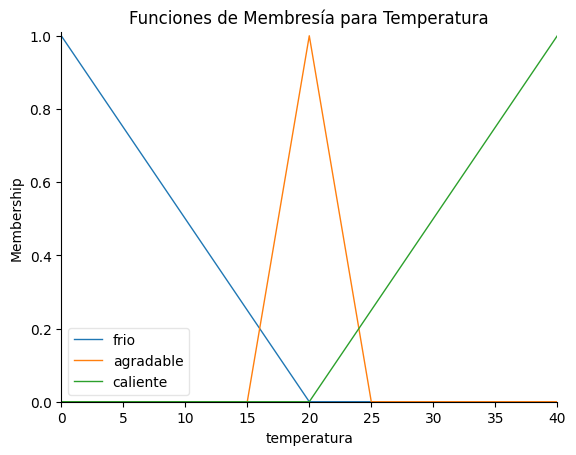

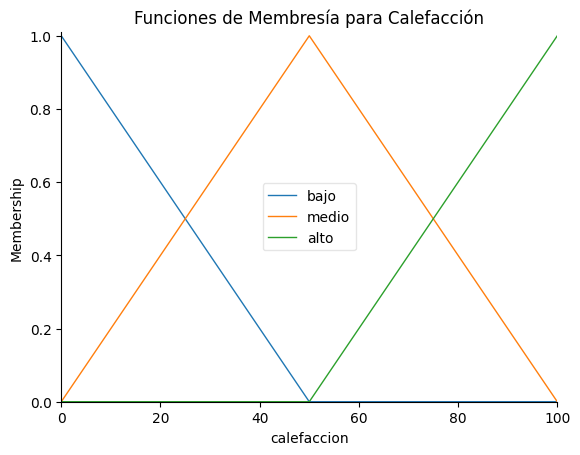

Nivel de calefacción recomendado: 50.29%


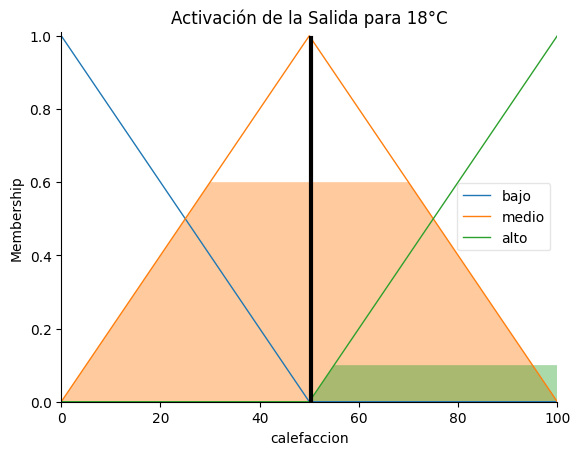

In [12]:
# Instalamos la librería scikit-fuzzy en Google Colab (ejecutar solo una vez).
!pip install -U scikit-fuzzy

# Importamos las bibliotecas necesarias.
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --- Explicación general ---
# Este ejemplo controla la calefacción de una habitación.
# Entrada: Temperatura actual (en grados Celsius).
# Salida: Nivel de calefacción (bajo, medio, alto).
# Idea básica: Si hace frío, aumentamos la calefacción; si hace calor, la reducimos.
# Usamos lógica fuzzy para manejar transiciones suaves entre categorías como "frío" y "caliente".

# --- Paso 1: Definir las variables fuzzy ---

# Variable de entrada: Temperatura actual.
# Universo: De 0°C a 40°C (rango típico de una habitación).
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), 'temperatura')

# Definimos funciones de membresía simples usando trimf (triangular).
# - Frío: Temperaturas bajas (0-20°C).
# - Agradable: Temperaturas intermedias (15-25°C).
# - Caliente: Temperaturas altas (20-40°C).
temperatura['frio'] = fuzz.trimf(temperatura.universe, [0, 0, 20])
temperatura['agradable'] = fuzz.trimf(temperatura.universe, [15, 20, 25])
temperatura['caliente'] = fuzz.trimf(temperatura.universe, [20, 40, 40])

# Graficamos para visualizar.
# Significado: Muestra cómo un valor de temperatura pertenece a cada categoría.
# Ej: 18°C tiene membresía alta en "frio" y baja en "agradable".
temperatura.view()
plt.title('Funciones de Membresía para Temperatura')
plt.show()

# Variable de salida: Nivel de calefacción.
# Universo: De 0% (apagado) a 100% (máximo).
calefaccion = ctrl.Consequent(np.arange(0, 101, 1), 'calefaccion')

# Funciones de membresía para la salida.
# - Bajo: Calefacción mínima.
# - Medio: Calefacción moderada.
# - Alto: Calefacción máxima.
calefaccion['bajo'] = fuzz.trimf(calefaccion.universe, [0, 0, 50])
calefaccion['medio'] = fuzz.trimf(calefaccion.universe, [0, 50, 100])
calefaccion['alto'] = fuzz.trimf(calefaccion.universe, [50, 100, 100])

# Graficamos.
# Significado: Muestra los posibles niveles de calefacción que el sistema puede decidir.
calefaccion.view()
plt.title('Funciones de Membresía para Calefacción')
plt.show()

# --- Paso 2: Definir las reglas fuzzy ---
# Reglas simples basadas en sentido común:
# 1. Si la temperatura es fría, la calefacción debe ser alta.
# 2. Si la temperatura es agradable, la calefacción debe ser media.
# 3. Si la temperatura es caliente, la calefacción debe ser baja.

reglas = [
    ctrl.Rule(temperatura['frio'], calefaccion['alto']),
    ctrl.Rule(temperatura['agradable'], calefaccion['medio']),
    ctrl.Rule(temperatura['caliente'], calefaccion['alto'])
]

# Explicación: Cada regla conecta una condición de entrada con una acción de salida.
# El sistema evaluará todas las reglas y combinará sus efectos.

# --- Paso 3: Crear el sistema de control ---
controlador = ctrl.ControlSystem(reglas)
simulador = ctrl.ControlSystemSimulation(controlador)

# --- Paso 4: Simular con un valor de ejemplo ---
# Probamos con una temperatura de 18°C.
simulador.input['temperatura'] = 18
simulador.compute()

# Mostramos el resultado.
print(f"Nivel de calefacción recomendado: {simulador.output['calefaccion']:.2f}%")

# Graficamos la activación de la salida.
# Significado: Muestra cómo las reglas afectan la salida para 18°C.
# La sombra indica la contribución de cada categoría, y la línea vertical es el valor final.
calefaccion.view(sim=simulador)
plt.title('Activación de la Salida para 18°C')
plt.show()

# --- Fin del ejemplo ---
# Puedes cambiar el valor de temperatura en simulador.input y ejecutar de nuevo.
# Ej: Prueba con 22°C o 30°C para ver cómo cambia la decisión.